In [4]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import decoupler as dc

In [5]:
plt.rcParams['figure.dpi'] = 150            # higher resolution


# Fig. S8a

In [174]:
def generate_deg_direction_heatmap(degs_raw, tissue, celltype, ordered_genotypes):
    df = degs_raw[(degs_raw['tissue'] == tissue) & (degs_raw['celltype'] == celltype)].copy()

    # Parse genotype1 vs genotype2
    df[['geno1', 'geno2']] = (
        df['comparison']
        .str.replace('Genotype_', '', regex=False)
        .str.split('_vs_', expand=True)
    )

    # Determine up/down direction based on log2FoldChange
    df['up'] = np.where(df['log2FoldChange'] > 0, df['geno1'], df['geno2'])
    df['down'] = np.where(df['log2FoldChange'] > 0, df['geno2'], df['geno1'])

    # Build the matrix
    table = pd.DataFrame(0, index=ordered_genotypes, columns=ordered_genotypes)

    for (up, down), group in df.groupby(['up', 'down']):
        if up in ordered_genotypes and down in ordered_genotypes:
            table.loc[up, down] = group['gene_name'].nunique()

    # Plot
    plt.figure(figsize=(5, 4.5))
    sns.heatmap(table,
                cmap="rocket",
                annot=True,
                fmt='d',
                cbar_kws={"label": "# DEGs"})

    plt.title(f"# DEGs in {celltype}", fontsize=16)
    plt.xlabel("Downregulated genotype")
    plt.ylabel("Upregulated genotype")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [170]:
tissue = 'Gastrocnemius'
celltype = 'skeletal muscle satellite cell'
ordered_genos = ['AJ', 'B6J', '129S1J', 'NODJ', 'NZOJ', 'CASTJ', 'PWKJ', 'WSBJ']

degs_all = pd.read_csv('/share/crsp/lab/seyedam/share/igvf_pipeline/figures/specificity/sig_degs_all_tissues.csv', index_col=0)



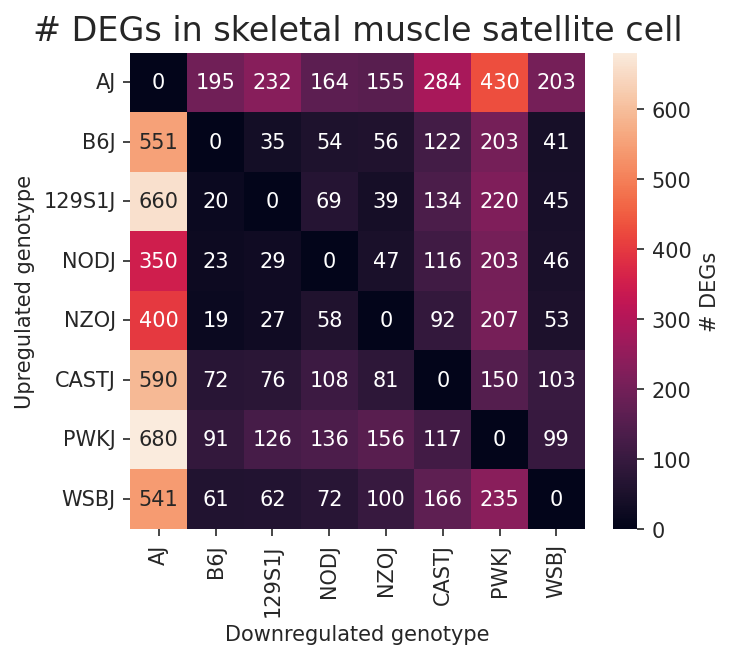

In [175]:
generate_deg_direction_heatmap(degs_all, tissue, celltype, ordered_genos)


# Fig. S8b

In [176]:
celltypes = ['skeletal_muscle_satellite_cell', 'type_IIa_myonucleus', 
             'type_IIb_myonucleus', 'type_IIx_myonucleus', 'type_I_myonucleus']


pdata_list = []

for celltype in celltypes:
    pdata = sc.read_h5ad(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/pseudobulk/celltype_pseudobulk/Gastrocnemius/Gastrocnemius_{celltype}_pseudobulk.h5ad')

    pbdata = dc.pp.pseudobulk(pdata,
                              sample_col="Genotype",
                              groups_col=None,
                              #layer = 'cellbender_counts',
                              mode='sum',
                              skip_checks=True,
                             )
        
    sc.pp.normalize_total(pbdata, target_sum=1e6) 
    
    pdata_list.append(pbdata)
    

In [177]:
gene = "Dysf"
heatmap_df = pd.DataFrame()

for i, celltype in enumerate(celltypes):
    pdata = pdata_list[i]
    
    if gene in pdata.var_names:
        expr_values = pdata[:, gene].X.toarray().flatten()  # Extract RPM values
        genotypes = pdata.obs["Genotype"].values  # Extract genotype labels
        
        temp_df = pd.DataFrame(data=[expr_values], columns=genotypes, index=[celltype])
        
        heatmap_df = pd.concat([heatmap_df, temp_df])

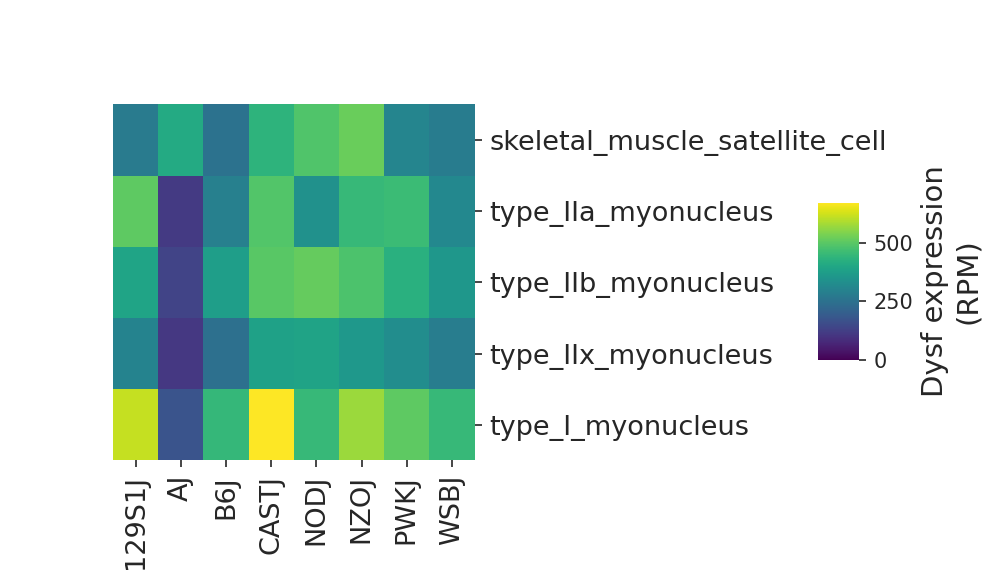

In [178]:
sns.set_style("ticks")

desired_order = ['129S1J', 'AJ', 'B6J', 'CASTJ', 'NODJ', 'NZOJ', 'PWKJ', 'WSBJ']
heatmap_df = heatmap_df[desired_order]

g = sns.clustermap(
    heatmap_df, 
    cmap="viridis", 
    col_cluster=False,  
    row_cluster=False,  
    linewidths=0,  
    figsize=(5.5, 3.5),
    vmin = 0,
    cbar_pos=(1, 0.3, 0.05, 0.3)  
)

plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=13)
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), fontsize=13)

g.cax.set_ylabel(f"{gene} expression\n(RPM)", fontsize=14)

plt.savefig(f"../supp_fig7/{gene}_pseudobulk_expression_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()


# Fig. S8c

In [1]:
import Topyfic
# pip install anndata==0.7.6


In [2]:
tissue = "Satellite"

In [6]:
adata_obs_df = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')


In [7]:
k = 10


In [13]:
cell_meta = adata_obs_df
cell_meta.reset_index(inplace=True)
cell_meta = cell_meta[['cellID','Genotype','Sex']]

analysis_tissue = Topyfic.read_topModel(f"/share/crsp/lab/seyedam/share/igvf_pipeline/topyfic/Satellite_regulatory_only/analysis_{tissue}_{k}.p")
df = analysis_tissue.cell_participation.to_df()
df = df.reset_index()
merged_df = pd.merge(df, cell_meta, on='cellID')
merged_df.to_csv('../supp_fig8/satellite_cell_participation.csv')

merged_df['Genotype'] = merged_df['Genotype'].astype(str)
df_percentage = merged_df.groupby('Genotype')[['Topic_1', 'Topic_2', 'Topic_3', 'Topic_4', 'Topic_5', 'Topic_6', 'Topic_7', 'Topic_8', 'Topic_9']].sum()
df_percentage = df_percentage.div(df_percentage.sum(axis=1), axis=0) * 100  # Multiplying by 100 to get percentages
df_pivot=df_percentage


Reading TopModel done!


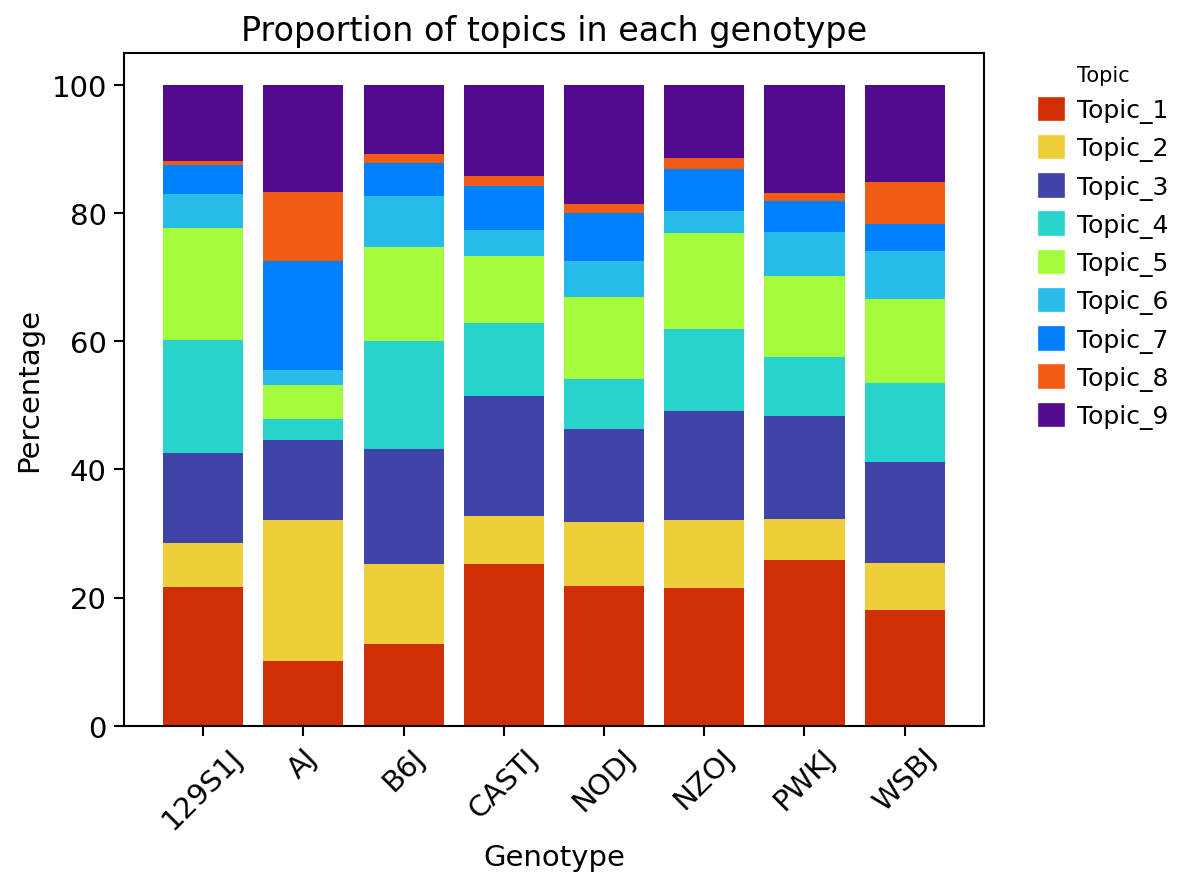

In [16]:
df_pivot = (
    merged_df
    .groupby('Genotype')
    [[f'Topic_{i}' for i in range(1, 10)]]
    .mean()
    * 100  # optional: convert to %
)

topic_order = [f'Topic_{i}' for i in range(1, 10)]
df_pivot = df_pivot[topic_order]

topic_dict = {
    'Topic_1': '#D02F05',  
    'Topic_2': '#EECF3A',             
    'Topic_3': '#4043A7',               
    'Topic_4': '#28d3cc',  
    'Topic_5': '#A4FC3C',        
    'Topic_6': '#28BCEB',              
    'Topic_7': '#007FFF',        
    'Topic_8': '#F05C13',
    'Topic_9': '#520b8c'   
}

plt.figure(figsize=(8, 6))
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

bottom = None
for topic in topic_order:
    plt.bar(
        df_pivot.index,
        df_pivot[topic],
        color=topic_dict[topic],
        label=topic,
        bottom=bottom
    )
    if bottom is None:
        bottom = df_pivot[topic].copy()
    else:
        bottom += df_pivot[topic]

plt.xlabel('Genotype', fontsize=14)
plt.ylabel('Percentage', fontsize=14)
plt.title('Proportion of topics in each genotype', fontsize=16)

handles = [
    plt.Rectangle((0,0),1,1, color=topic_dict[topic]) for topic in topic_order
]
labels = topic_order
plt.legend(handles, labels, title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()

plt.savefig('../fig5/satellite_k10_topic_summary_barplot.pdf')
plt.show()


# Fig. S8d

In [30]:
gene_weights = analysis_tissue.top_model.get_gene_weights()


In [32]:
reg_genes = pd.read_csv("../supp_fig8/gene_display_table_7categories.csv", index_col = 0)

gene_weights.reset_index(inplace=True)
gene_weights.rename(columns={'index': 'gene_name'}, inplace=True)

gene_weights = pd.merge(gene_weights, reg_genes, how='left', on='gene_name')

genes = ['Pax3','Pax7',
         'Ankrd1','Ppargc1a','Hoxc4','Hoxc5','Nfix',
         'Mef2c','Ppargc1a','Smyd1','Klf7','Tbx15','Notch1',
        'Zeb1','Zeb2','Nfkb1','Sox6','Mir133a-1','Actn2']
 
# Atf3, Klf7 preserves quiescent
# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9569562/

filtered_df = gene_weights[gene_weights['display_name'].isin(genes)] #all_genes_unique
filtered_df.drop(columns=['gene_name','biotype','keep'], inplace=True)
filtered_df.set_index('display_name', inplace=True)


Text(770.8333333333331, 0.5, '')

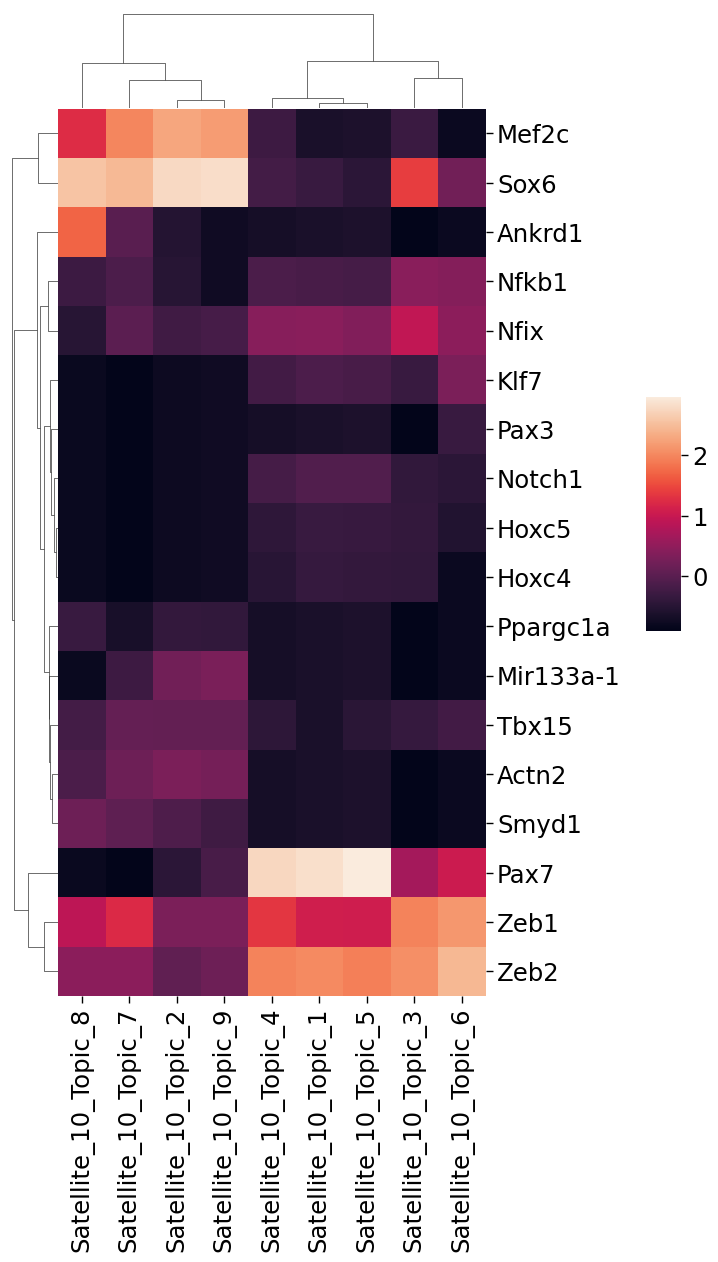

In [33]:
sns.set_context("paper", font_scale=2) # set some nice global plotting settings.
g = sns.clustermap(filtered_df, 
                   z_score=1,
                   col_cluster=True, 
                   dendrogram_ratio=0.1, 
                   cbar_pos=(0.95, 0.5, 0.05, 0.18),
                   row_cluster=True, 
                   figsize=(7, 13),)

g.ax_heatmap.set_ylabel('')
